In [28]:
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0



In [ ]:
model = tf.keras.models.Sequential(
    [
        layers.Flatten(input_shape=(28,28)),
        layers.Dense(128, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax')
    ]
)

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()
history = model.fit(x_train, y_train, epochs=5, validation_split=0.1)

print("\nТестування моделі:")
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"Точність на тестових даних: {test_acc:.4f}")

/home/maksym_vivdychenko/.conda/envs/tf_lab/lib/python3.10/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,282 (462.04 KB)

 Trainable params: 118,282 (462.04 KB)

 Non-trainable params: 0 (0.00 B)

Початок навчання...
Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9262 - loss: 0.2474 - val_accuracy: 0.9677 - val_loss: 0.1075
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9683 - loss: 0.1038 - val_accuracy: 0.9737 - val_loss: 0.0874
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9783 - loss: 0.0710 - val_accuracy: 0.9710 - val_loss: 0.0997
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9833 - loss: 0.0531 - val_accuracy: 0.9773 - val_loss: 0.0818
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9869 - loss: 0.0406 - val_accuracy: 0.9765 - val_loss: 0.0813

Тестування моделі:
313/313 - 1s - 2ms/step - accuracy: 0.9738 - loss: 0.0889
Точність на тестових даних: 0.9738


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

--- Метрики якості ---
Accuracy:  0.9738
Precision: 0.9735
Recall:    0.9737
F-Score:   0.9735


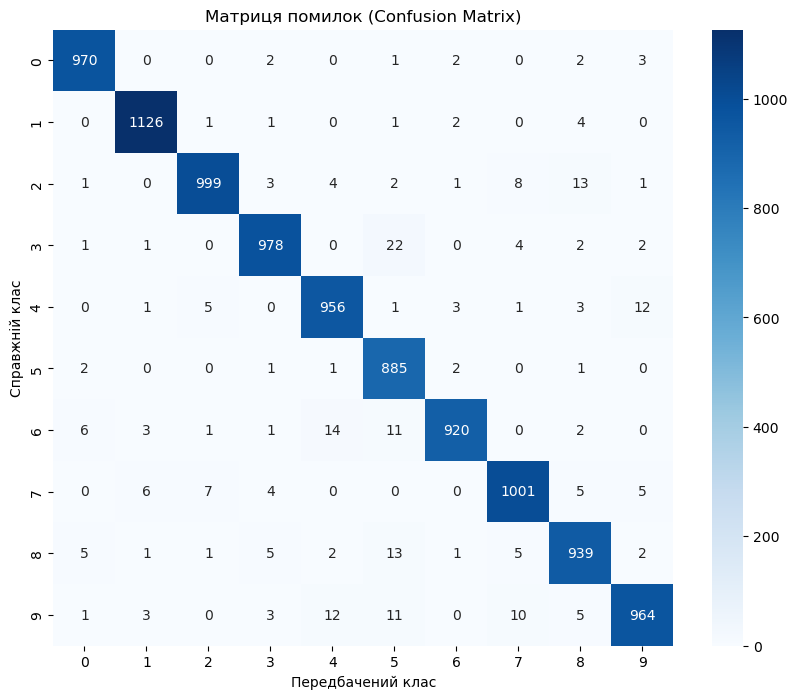


Детальний звіт класифікації:

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.99      0.97      0.98      1032
           3       0.98      0.97      0.97      1010
           4       0.97      0.97      0.97       982
           5       0.93      0.99      0.96       892
           6       0.99      0.96      0.97       958
           7       0.97      0.97      0.97      1028
           8       0.96      0.96      0.96       974
           9       0.97      0.96      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns

y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
f_score = f1_score(y_test, y_pred, average='macro')

print("\n--- Метрики якості ---")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F-Score:   {f_score:.4f}")

# Побудова матриці помилок
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Матриця помилок (Confusion Matrix)')
plt.ylabel('Справжній клас')
plt.xlabel('Передбачений клас')
plt.show()

# Детальний звіт по кожному класу
print("\nДетальний звіт класифікації:\n")
print(classification_report(y_test, y_pred))

In [ ]:
import cv2
import numpy as np

def predict_my_drawing(image_path, model):
    
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    if img.shape != (28, 28):
        img = cv2.resize(img, (28, 28))

    img = cv2.bitwise_not(img)

    img = img / 255.0

    img_for_model = img.reshape(1, 28, 28)

    predictions = model.predict(img_for_model, verbose=0) 
    
    predicted_number = np.argmax(predictions)
    confidence = np.max(predictions) * 100

    plt.figure(figsize=(4, 4))
    plt.imshow(img, cmap='gray')
    plt.show()
    
    print(f"{predicted_number} (Впевненість: {confidence:.2f}%)")
    
    return predicted_number

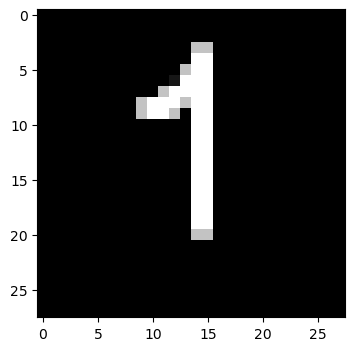

Це 1 (Впевненість: 99.81%)


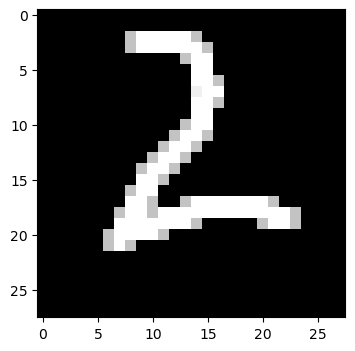

Це 2 (Впевненість: 100.00%)


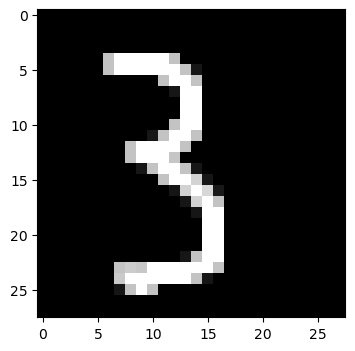

Це 3 (Впевненість: 99.97%)


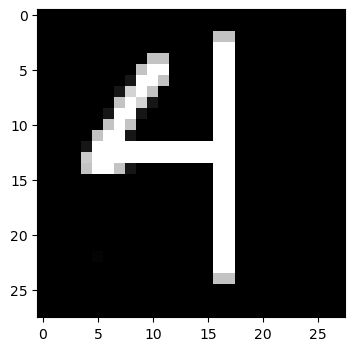

Це 4 (Впевненість: 99.80%)


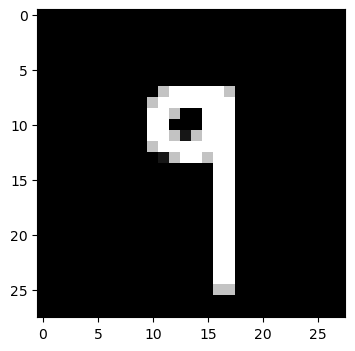

Це 9 (Впевненість: 99.98%)


In [40]:
number = predict_my_drawing('/home/maksym_vivdychenko/Pictures/1.png',model)
number = predict_my_drawing('/home/maksym_vivdychenko/Pictures/2.png',model)
number = predict_my_drawing('/home/maksym_vivdychenko/Pictures/3.png',model)
number = predict_my_drawing('/home/maksym_vivdychenko/Pictures/4.png',model)
number = predict_my_drawing('/home/maksym_vivdychenko/Pictures/9.png',model)